Import các thư viện cần thiết như Numpy và Pandas

In [2]:
import numpy as np
import pandas as pd
print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.3.5
2.3.3


Đọc datasets

In [3]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [4]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [5]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

BIỂU ĐỒ BIẾN MỤC TIÊU

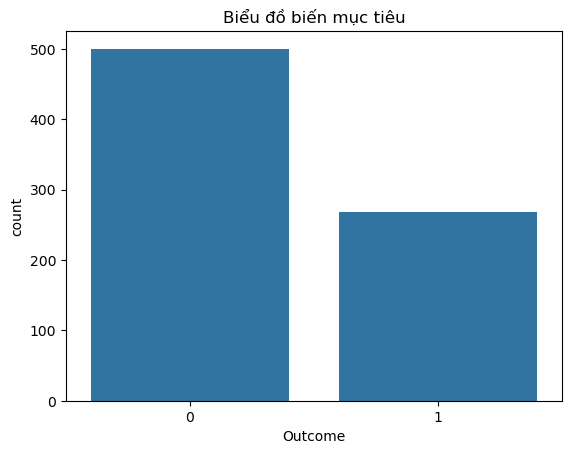

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.title('Biểu đồ biến mục tiêu')

plt.show()

In [7]:

df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df['Outcome'].value_counts(normalize = True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

=> Biểu đồ cho thấy số lượng người không mắc tiểu đường( Outcome = 0) nhiều hơn người bị mắc tiểu đường (Outcome = 1). 
Dữ liệu bị mất cân bằng giữa hai lớp.

**Distribution Plots (Histogram, KDE c numerical features)**

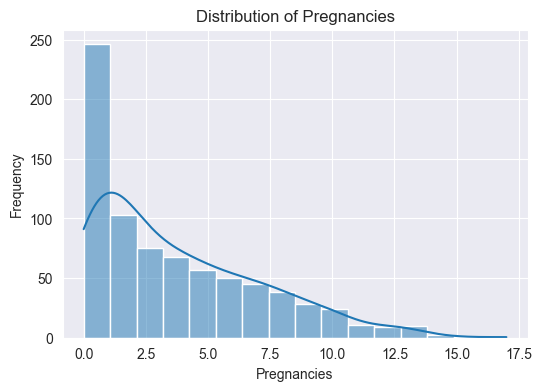

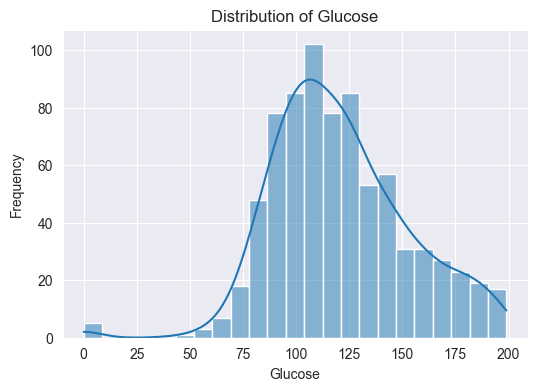

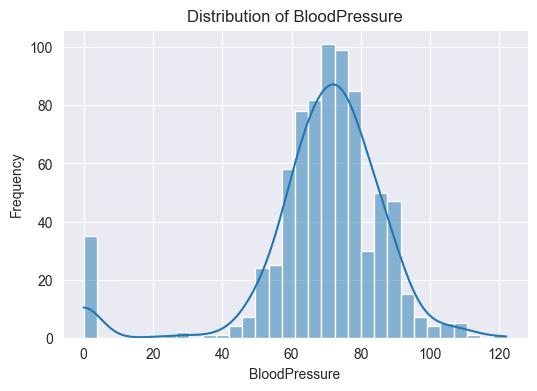

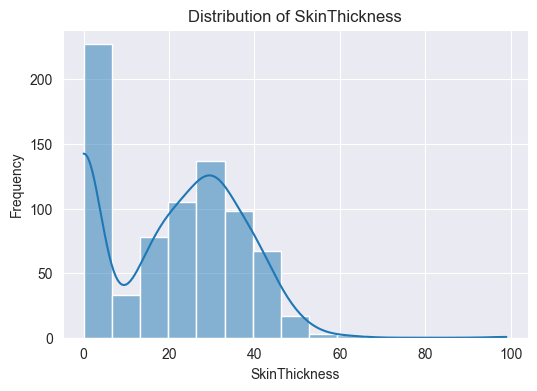

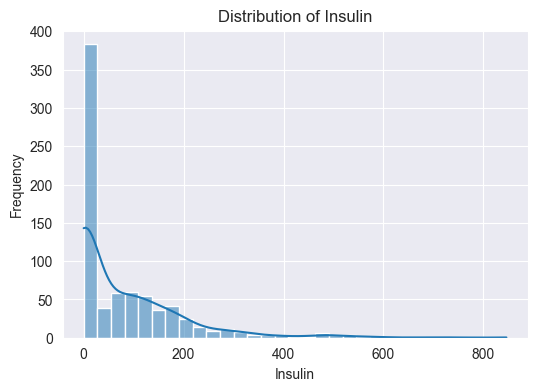

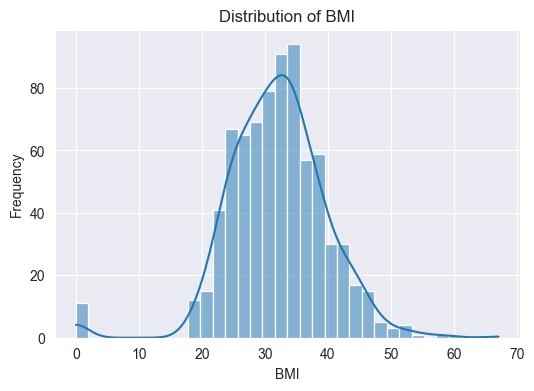

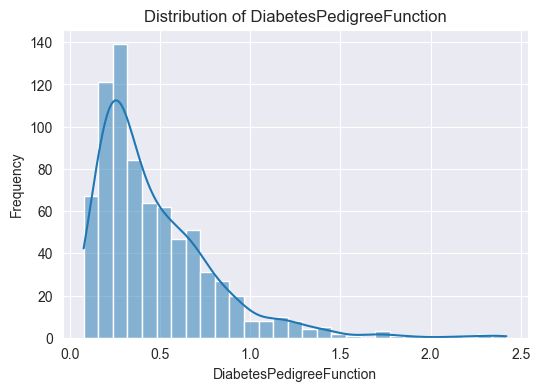

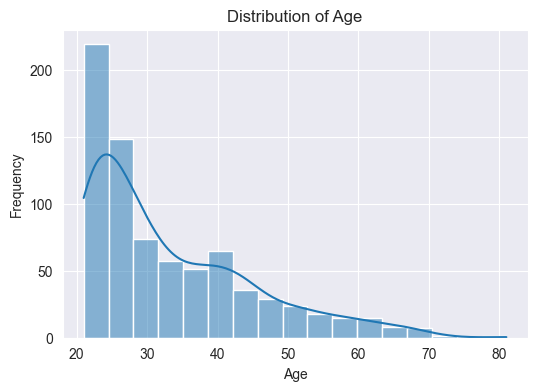

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetes.csv")

numerical_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

CORRELATION HEATMAP

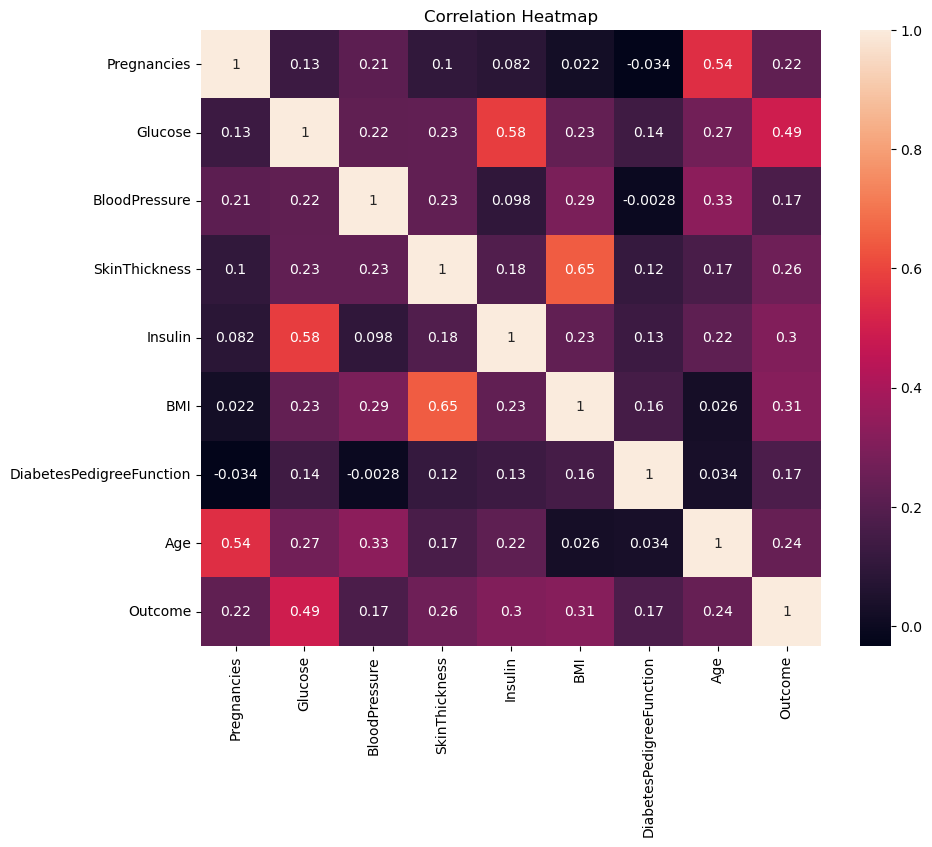

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
cmap="coolwwarm"
plt.title('Correlation Heatmap')
plt.show()

=> Biểu đồ correlation heatmap cho thấy mối tương quan giữa các biến trong dataset.
+ "Glucose" có hệ số tương quan cao nhất với "Outcome" là 0.49 -> lượng đường cao dẫn đến khả năng mắc bệnh tiểu đường.

**Categorical Analysis**

**Bar plot**

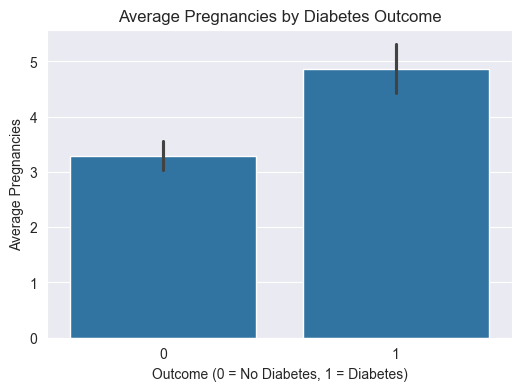

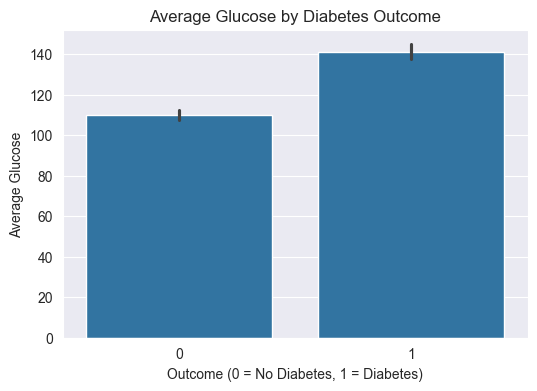

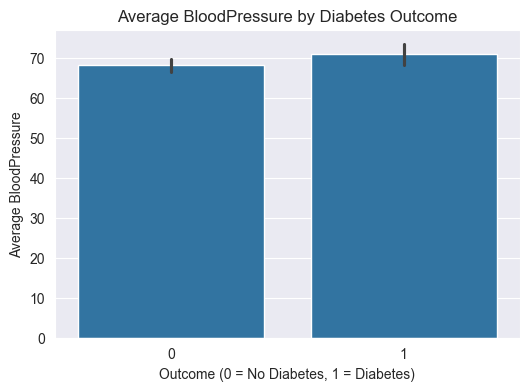

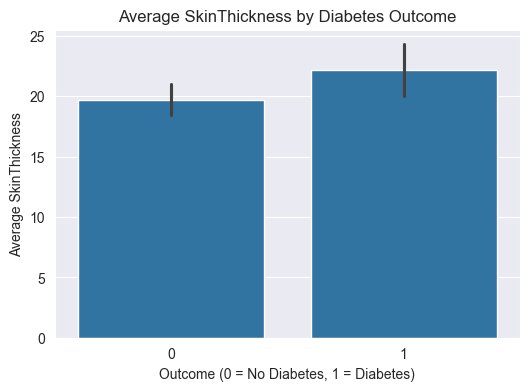

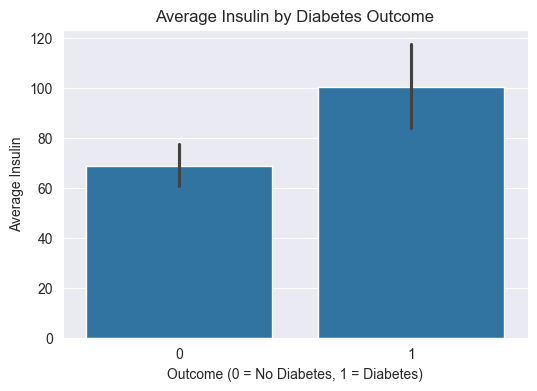

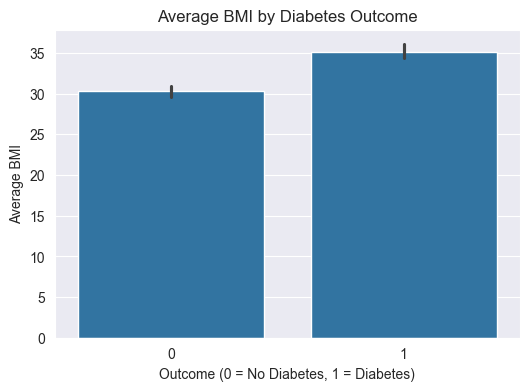

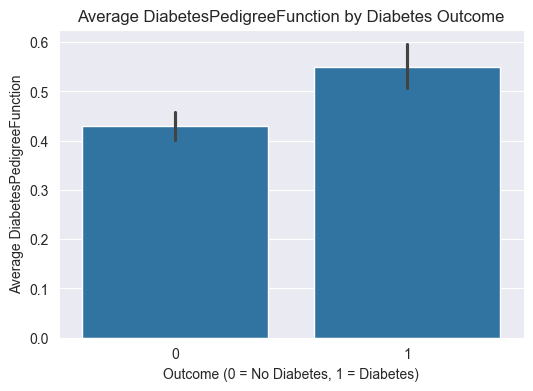

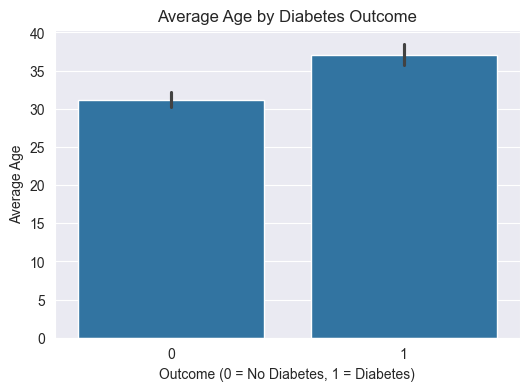

In [10]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Outcome', y=col, data=df)

    plt.title(f'Average {col} by Diabetes Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(f'Average {col}')

    plt.show()

**Count plot**

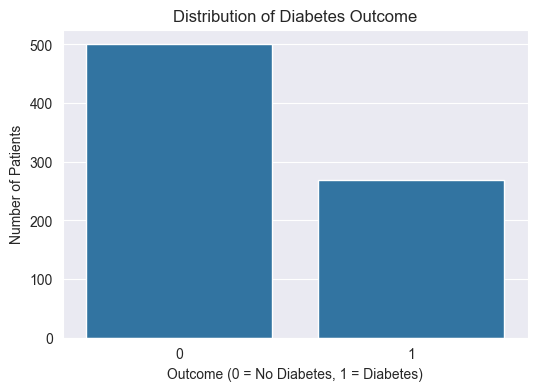

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

PHÂN TÍCH BOXPLOT (PHÁT HIỆN OUTLIERS)

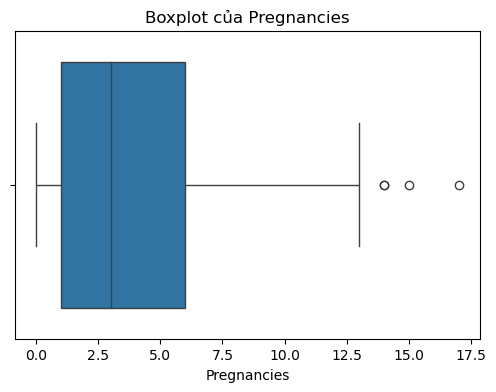

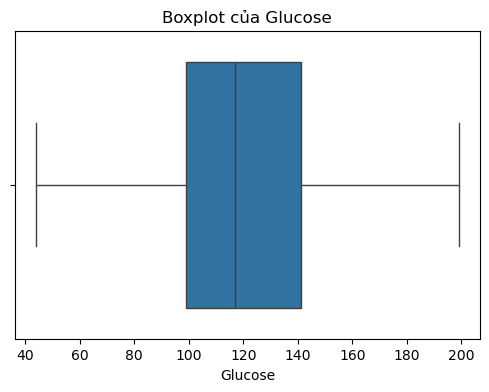

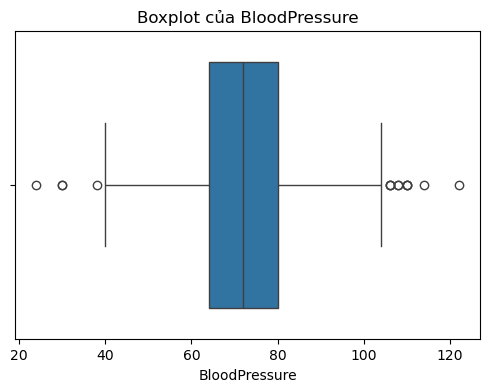

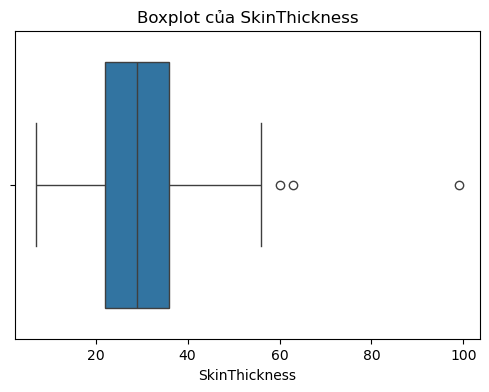

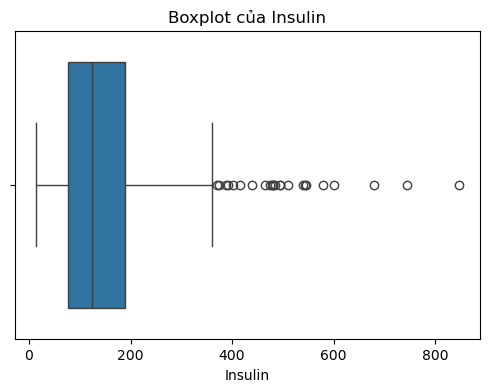

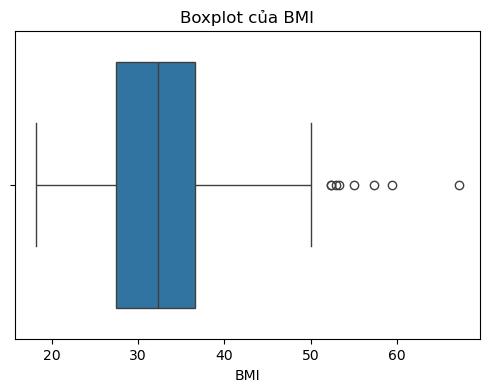

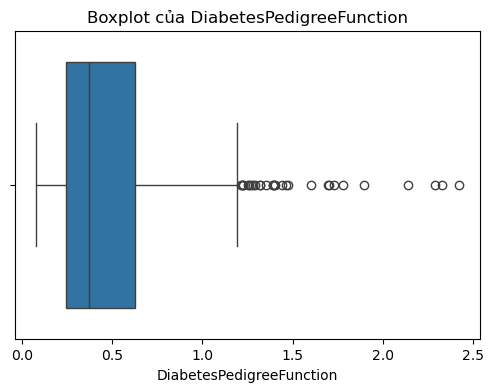

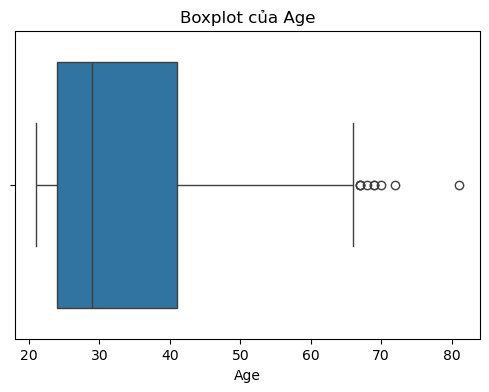

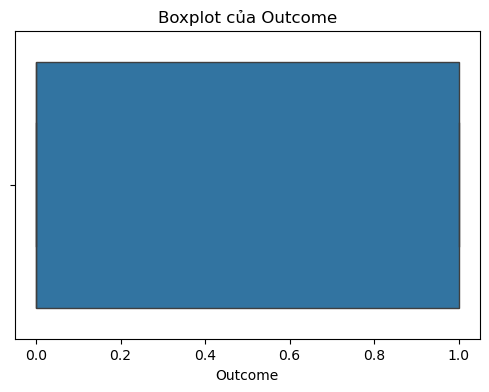

In [11]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot của {col}')
    
    plt.show()

PHÂN TÍCH OUTLIERS BẰNG PHƯƠNG PHÁP IQR

In [13]:
outlier_results = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_results)

print('Bảng kết quả phát hiện outliers:')
print(outlier_df)


Bảng kết quả phát hiện outliers:
                    Feature        Q1         Q3       IQR  Lower Bound  Upper Bound  Number of Outliers
0               Pregnancies   1.00000    6.00000    5.0000       -6.500       13.500                   4
1                   Glucose  99.00000  141.00000   42.0000       36.000      204.000                   0
2             BloodPressure  64.00000   80.00000   16.0000       40.000      104.000                  14
3             SkinThickness  22.00000   36.00000   14.0000        1.000       57.000                   3
4                   Insulin  76.25000  190.00000  113.7500      -94.375      360.625                  24
5                       BMI  27.50000   36.60000    9.1000       13.850       50.250                   8
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825       -0.330        1.200                  29
7                       Age  24.00000   41.00000   17.0000       -1.500       66.500                   9
8                   Ou

KIỂM ĐỊNH THỐNG KÊ T-TEST

In [19]:
from scipy.stats import ttest_ind
ttest_results = []

for col in numeric_cols:
    
    if col != 'Outcome':
        
        group0 = df[df['Outcome'] == 0][col]
        group1 = df[df['Outcome'] == 1][col]
        
        t_stat, p_value = ttest_ind(group0, group1)
        
        ttest_results.append({
            'Feature': col,
            'T-statistic': t_stat,
            'P-value': p_value
        })

ttest_df = pd.DataFrame(ttest_results)

print('Kết quả kiểm định t-test:')
print(ttest_df)

Kết quả kiểm định t-test:
                    Feature  T-statistic       P-value
0               Pregnancies    -6.298431  5.065127e-10
1                   Glucose          NaN           NaN
2             BloodPressure          NaN           NaN
3             SkinThickness          NaN           NaN
4                   Insulin          NaN           NaN
5                       BMI          NaN           NaN
6  DiabetesPedigreeFunction    -4.885826  1.254607e-06
7                       Age    -6.792688  2.209975e-11


NHẬN XÉT KẾT QUẢ KIỂM ĐỊNH

In [21]:
for i,row in ttest_df.iterrows():
    
    if row['P-value'] < 0.05:
        print(f"{row['Feature']} -> Có sự khác biệt, có ý nghĩa thống kê (p = {row['P-value']:.5f})")
    else:
        print(f"{row['Feature']} -> Không có sự khác biệt đáng kể (p = {row['P-value']:.5f})")

Pregnancies -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Glucose -> Không có sự khác biệt đáng kể (p = nan)
BloodPressure -> Không có sự khác biệt đáng kể (p = nan)
SkinThickness -> Không có sự khác biệt đáng kể (p = nan)
Insulin -> Không có sự khác biệt đáng kể (p = nan)
BMI -> Không có sự khác biệt đáng kể (p = nan)
DiabetesPedigreeFunction -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Age -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)


 KIỂM ĐỊNH CHI-SQUARE 

In [22]:
from scipy.stats import chi2_contingency


df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,100],
    labels=['20-30','30-40','40-50','50-60','60+']
)

contingency_table = pd.crosstab(df['Age_Group'], df['Outcome'])

print('Bảng chéo Age_Group và Outcome:')
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print('Kết quả kiểm định Chi-Square:')
print('Chi-square statistic:', chi2)
print('P-value:', p)
print('Degrees of freedom:', dof)

print('Bảng giá trị kỳ vọng:')
print(expected)



Bảng chéo Age_Group và Outcome:
Outcome      0   1
Age_Group         
20-30      327  90
30-40       81  76
40-50       49  64
50-60       23  31
60+         20   7
Kết quả kiểm định Chi-Square:
Chi-square statistic: 81.6612857019655
P-value: 7.74411254791731e-17
Degrees of freedom: 4
Bảng giá trị kỳ vọng:
[[271.484375   145.515625  ]
 [102.21354167  54.78645833]
 [ 73.56770833  39.43229167]
 [ 35.15625     18.84375   ]
 [ 17.578125     9.421875  ]]


NHẬN XÉT CHI-SQUARE 

In [23]:
if p < 0.05:
    print('Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome')
else:
    print('Không có bằng chứng về mối quan hệ giữa Age_Group và Outcome')

Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome
